## EDA and data cleaning


DAG Focus: Policy Intervention -> Business Size Structure -> Economic Resilience -> Employment Rate -> Economic Output (GVA)

In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt 
import geopandas as gpd

In [2]:
# Load the dataset
df = pd.read_csv("features.csv")
df.head()

,LSOA21CD,LSOA21NM,LSOA21NMW,RUC21CD,RUC21NM,Urban_rura,Shape_Leng,Shape__Are,Shape__Len,MSOA21CD,...,share_enterprises_industrial_2025_msoa,share_enterprises_kibs_2025_msoa,share_enterprises_anchor_2025_msoa,enterprises_per_1k_residents_2025,share_enterprises_public_2025_msoa,share_enterprises_private_2025_msoa,bus_stop_count,area_km2,bus_stop_density,dist_to_primary_m
0,E01015471,Swindon 028A,NaN,UN1,Urban: Nearer to a major town or city,Urban,4013.589687,5.013996e+05,4013.589687,E02006849,...,0.020833,0.458333,0.083333,105.448155,0.000000,1.000000,5,1.298791,3.849735,617.714131
1,E01015473,Swindon 008A,NaN,RSN1,Smaller rural: Nearer to a major town or city,Rural,25688.031740,1.524397e+07,25688.031738,E02003219,...,0.045752,0.405229,0.065359,351.401011,0.006536,0.993464,37,39.476058,0.937277,574.697536
2,E01015475,Swindon 015A,NaN,UN1,Urban: Nearer to a major town or city,Urban,2099.250451,2.145225e+05,2099.250451,E02003226,...,0.016129,0.290323,0.064516,124.298316,0.000000,1.000000,10,0.554698,18.027840,350.510113
3,E01015477,Swindon 015C,NaN,UN1,Urban: Nearer to a major town or city,Urban,3276.800336,2.405209e+05,3276.800336,E02003226,...,0.016129,0.290323,0.064516,171.365395,0.000000,1.000000,5,0.621788,8.041327,473.126804
4,E01015478,Swindon 021A,NaN,UN1,Urban: Nearer to a major town or city,Urban,4188.002606,6.194380e+05,4188.002606,E02003232,...,0.033898,0.406780,0.067797,181.315304,0.000000,1.000000,6,1.601008,3.747640,58.398219


In [3]:
print(df.isna().sum())

LSOA21CD                                  0
LSOA21NM                                  0
LSOA21NMW                              1129
RUC21CD                                   0
RUC21NM                                   0
                                       ... 
share_enterprises_private_2025_msoa       0
bus_stop_count                            0
area_km2                                  0
bus_stop_density                          0
dist_to_primary_m                         0
Length: 83, dtype: int64


In [4]:
df_swindon = df[df["LSOA21NM"].str.contains("Swindon", case=False, na=False)]
df_swindon 


,LSOA21CD,LSOA21NM,LSOA21NMW,RUC21CD,RUC21NM,Urban_rura,Shape_Leng,Shape__Are,Shape__Len,MSOA21CD,...,share_enterprises_industrial_2025_msoa,share_enterprises_kibs_2025_msoa,share_enterprises_anchor_2025_msoa,enterprises_per_1k_residents_2025,share_enterprises_public_2025_msoa,share_enterprises_private_2025_msoa,bus_stop_count,area_km2,bus_stop_density,dist_to_primary_m
0,E01015471,Swindon 028A,NaN,UN1,Urban: Nearer to a major town or city,Urban,4013.589687,5.013996e+05,4013.589687,E02006849,...,0.020833,0.458333,0.083333,105.448155,0.000000,1.000000,5,1.298791,3.849735,617.714131
1,E01015473,Swindon 008A,NaN,RSN1,Smaller rural: Nearer to a major town or city,Rural,25688.031740,1.524397e+07,25688.031738,E02003219,...,0.045752,0.405229,0.065359,351.401011,0.006536,0.993464,37,39.476058,0.937277,574.697536
2,E01015475,Swindon 015A,NaN,UN1,Urban: Nearer to a major town or city,Urban,2099.250451,2.145225e+05,2099.250451,E02003226,...,0.016129,0.290323,0.064516,124.298316,0.000000,1.000000,10,0.554698,18.027840,350.510113
3,E01015477,Swindon 015C,NaN,UN1,Urban: Nearer to a major town or city,Urban,3276.800336,2.405209e+05,3276.800336,E02003226,...,0.016129,0.290323,0.064516,171.365395,0.000000,1.000000,5,0.621788,8.041327,473.126804
4,E01015478,Swindon 021A,NaN,UN1,Urban: Nearer to a major town or city,Urban,4188.002606,6.194380e+05,4188.002606,E02003232,...,0.033898,0.406780,0.067797,181.315304,0.000000,1.000000,6,1.601008,3.747640,58.398219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,E01033848,Swindon 024F,NaN,UN1,Urban: Nearer to a major town or city,Urban,2764.172295,4.581245e+05,2764.172295,E02003235,...,0.025000,0.400000,0.062500,198.019802,0.000000,1.000000,6,1.183455,5.069903,278.660134
1035,E01033849,Swindon 025G,NaN,UN1,Urban: Nearer to a major town or city,Urban,5527.353653,1.916267e+06,5527.353653,E02003236,...,0.044444,0.366667,0.066667,141.420490,0.000000,1.000000,18,4.948871,3.637194,823.245343
1036,E01033850,Swindon 025H,NaN,RSN1,Smaller rural: Nearer to a major town or city,Rural,23432.129310,1.842333e+07,23432.129310,E02003236,...,0.044444,0.366667,0.066667,210.970464,0.000000,1.000000,24,47.524835,0.504999,2401.481337
1047,E01033860,Swindon 028F,NaN,UN1,Urban: Nearer to a major town or city,Urban,3093.536938,4.921624e+05,3093.536938,E02006849,...,0.020833,0.458333,0.083333,129.729730,0.000000,1.000000,3,1.274531,2.353807,193.498452


In [5]:
print(df_swindon.isna().sum())

LSOA21CD                                 0
LSOA21NM                                 0
LSOA21NMW                              140
RUC21CD                                  0
RUC21NM                                  0
                                      ... 
share_enterprises_private_2025_msoa      0
bus_stop_count                           0
area_km2                                 0
bus_stop_density                         0
dist_to_primary_m                        0
Length: 83, dtype: int64


In [6]:
df_swindon = df_swindon.drop(columns=['LSOA21NMW'])


In [7]:
print(df_swindon.isna().sum())

LSOA21CD                               0
LSOA21NM                               0
RUC21CD                                0
RUC21NM                                0
Urban_rura                             0
                                      ..
share_enterprises_private_2025_msoa    0
bus_stop_count                         0
area_km2                               0
bus_stop_density                       0
dist_to_primary_m                      0
Length: 82, dtype: int64


In [8]:
df_swindon.describe().T

,count,mean,std,min,25%,50%,75%,max
Shape_Leng,140.0,4.703393e+03,5.863321e+03,1.372082e+03,2.392876e+03,2.934435e+03,4.193452e+03,3.706638e+04
Shape__Are,140.0,1.643425e+06,4.873112e+06,8.227357e+04,2.688533e+05,3.619270e+05,6.683902e+05,3.056605e+07
Shape__Len,140.0,4.703393e+03,5.863321e+03,1.372082e+03,2.392876e+03,2.934435e+03,4.193452e+03,3.706638e+04
VOA_hereditaments_2023,134.0,5.109701e+01,9.018134e+01,1.000000e+00,5.000000e+00,1.500000e+01,5.975000e+01,5.470000e+02
VOA_total_RV_2023,134.0,1.752413e+12,3.119087e+12,3.122326e+10,1.583240e+11,5.024735e+11,2.092682e+12,1.914120e+13
...,...,...,...,...,...,...,...,...
share_enterprises_private_2025_msoa,140.0,9.953454e-01,1.286293e-02,9.230769e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
bus_stop_count,140.0,7.357143e+00,5.769021e+00,1.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,3.700000e+01
area_km2,140.0,4.250898e+00,1.260433e+01,2.131071e-01,6.954987e-01,9.361267e-01,1.727098e+00,7.898399e+01
bus_stop_density,140.0,6.162995e+00,5.126822e+00,6.920344e-02,2.936390e+00,4.720655e+00,8.188122e+00,4.027971e+01


In [9]:
# Missing values — sorted, only show columns that have any
missing = df_swindon.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_swindon) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
LSOA GVA Estimates (millions),13,9.3
VOA_total_RV_2023,6,4.3
VOA_median_RV_2023,6,4.3
VOA_total_RV_million_2023,6,4.3
VOA_hereditaments_2023,6,4.3
VOA_median_RV_thousand_2023,6,4.3
VOA_hereditaments_2026,6,4.3
VOA_median_RV_2026,6,4.3
VOA_total_RV_2026,6,4.3
VOA_total_RV_million_2026,6,4.3


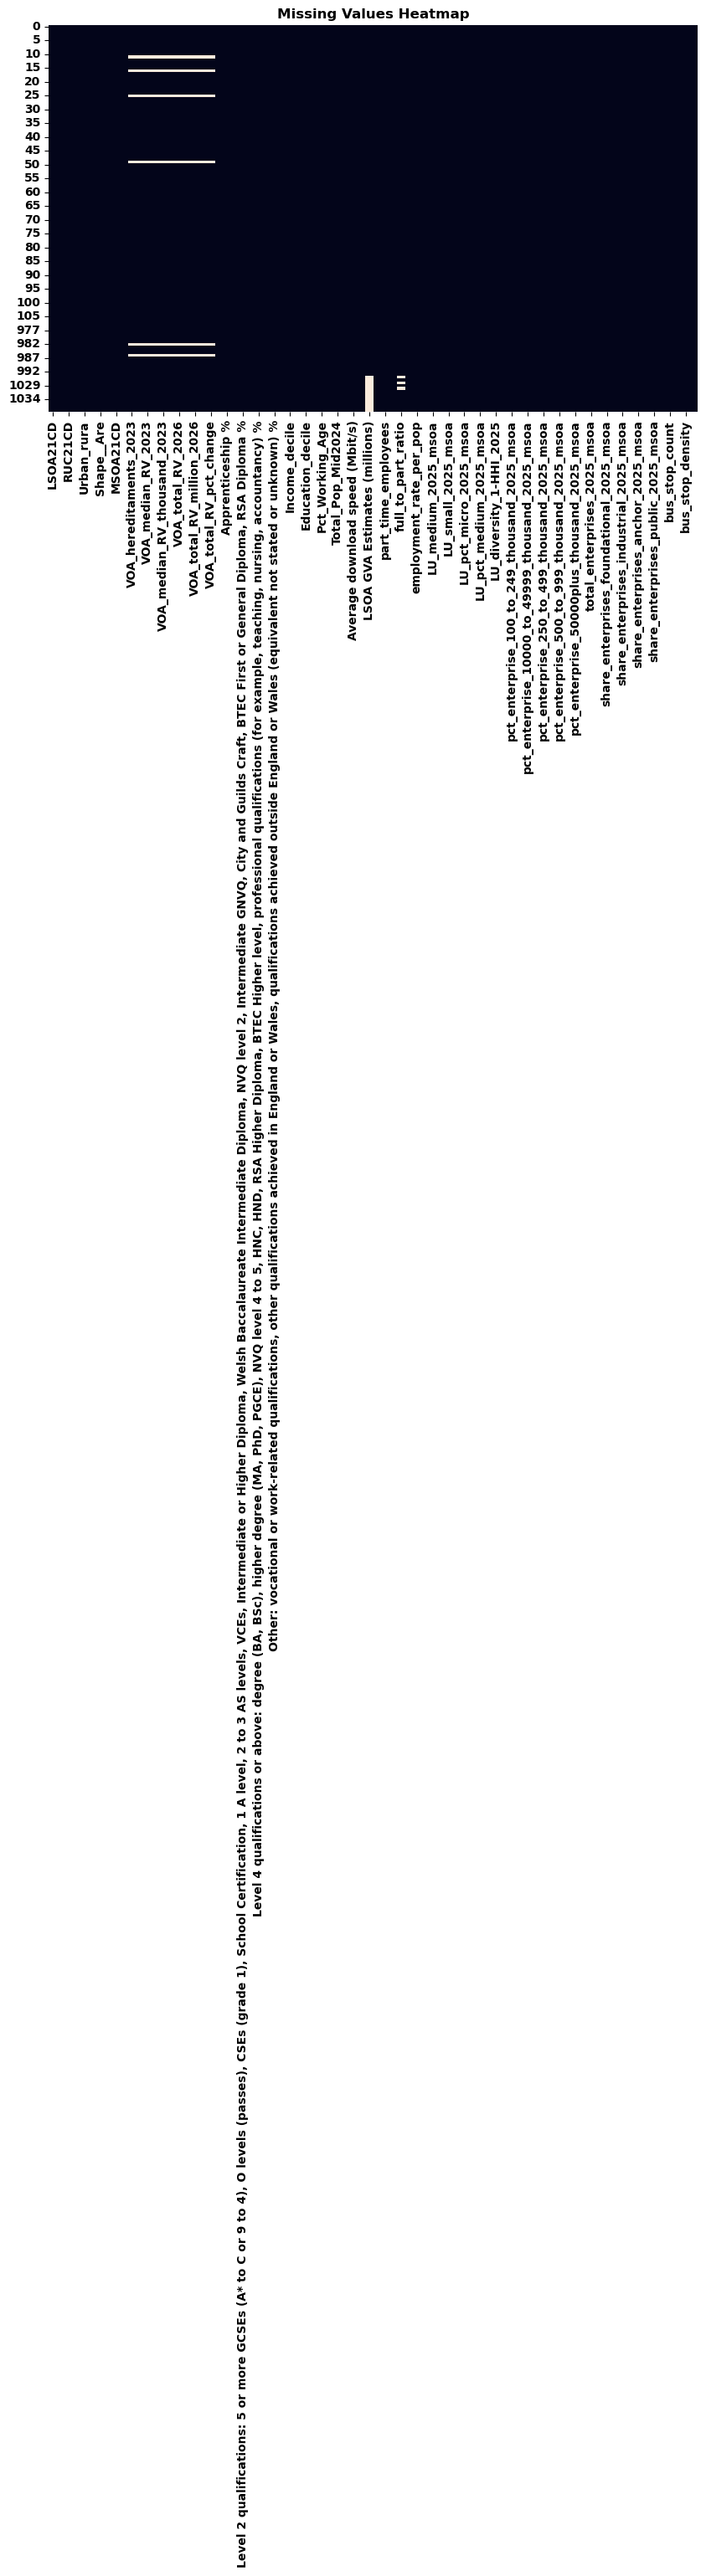

In [10]:
# Missing values summary
df_swindon.isna().sum().sort_values(ascending=False)

# Visualise missingness
plt.figure(figsize=(10,6))
sns.heatmap(df_swindon.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


### 1. Target Variable - GVA

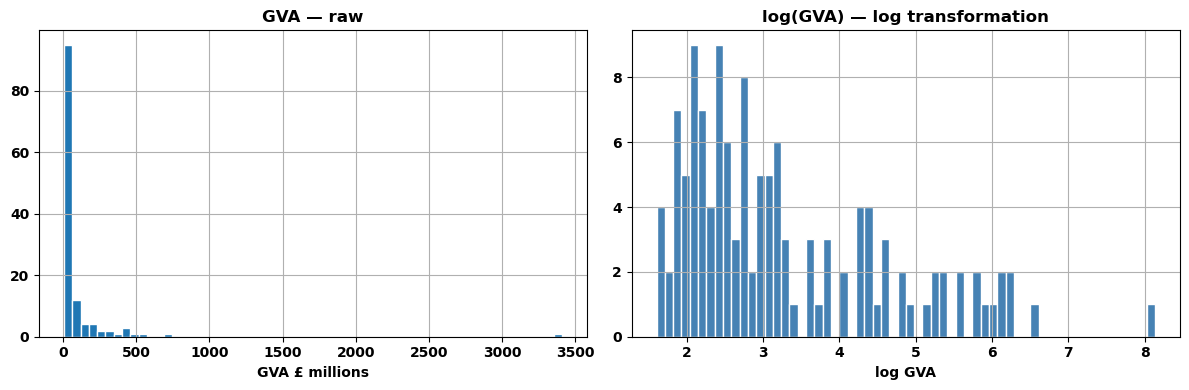

In [11]:
gva = df_swindon['LSOA GVA Estimates (millions)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gva.hist(bins=60, ax=axes[0], edgecolor='white')
axes[0].set_title('GVA — raw')
axes[0].set_xlabel('GVA £ millions')

np.log(gva).hist(bins=60, ax=axes[1], edgecolor='white', color='steelblue')
axes[1].set_title('log(GVA) — log transformation')
axes[1].set_xlabel('log GVA')

plt.tight_layout()


In [12]:
# Who are the extreme LSOAs?
df_gva = df_swindon.dropna(subset=['LSOA GVA Estimates (millions)'])
print('TOP 5 by GVA')
print(df_gva.nlargest(5, 'LSOA GVA Estimates (millions)')[['LSOA21NM', 'LSOA GVA Estimates (millions)', 'RUC21NM']])
print()
print('BOTTOM 5 by GVA')
print(df_gva.nsmallest(5, 'LSOA GVA Estimates (millions)')[['LSOA21NM', 'LSOA GVA Estimates (millions)', 'RUC21NM']])

TOP 5 by GVA
        LSOA21NM  LSOA GVA Estimates (millions)  \
28  Swindon 022C                       3412.047   
34  Swindon 010B                        706.386   
91  Swindon 014D                        520.949   
1   Swindon 008A                        495.260   
72  Swindon 009A                        457.800   

                                          RUC21NM  
28          Urban: Nearer to a major town or city  
34          Urban: Nearer to a major town or city  
91          Urban: Nearer to a major town or city  
1   Smaller rural: Nearer to a major town or city  
72          Urban: Nearer to a major town or city  

BOTTOM 5 by GVA
        LSOA21NM  LSOA GVA Estimates (millions)  \
49  Swindon 001F                          4.977   
16  Swindon 023D                          5.126   
40  Swindon 004C                          5.253   
65  Swindon 020E                          5.362   
62  Swindon 020B                          6.161   

                                         RUC

In [13]:
swindon_boroughs = gpd.read_file("map_source\LSOA_2021_EW_BFC_V10.shp")
 
swindon_lsoa = swindon_boroughs[swindon_boroughs["LSOA21NM"].str.contains("Swindon", case=False, na=False)]
swindon_lsoa.head(5)


<>:1: SyntaxWarning: invalid escape sequence '\L'
<>:1: SyntaxWarning: invalid escape sequence '\L'
C:\Users\User\AppData\Local\Temp\ipykernel_30592\1767843393.py:1: SyntaxWarning: invalid escape sequence '\L'
  swindon_boroughs = gpd.read_file("map_source\LSOA_2021_EW_BFC_V10.shp")


,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
14692,E01015471,Swindon 028A,NaN,413941,189671,51.6057,-1.80008,1914f574-6701-4969-b5e0-45d41bf2b6b2,"POLYGON ((414540.509 189985.863, 414471.445 18..."
14693,E01015473,Swindon 008A,NaN,417931,190349,51.6117,-1.74243,8c49be6b-239e-4f30-859c-97fa0ae3999e,"POLYGON ((418156.188 191166.5, 418160.8 191159..."
14694,E01015475,Swindon 015A,NaN,415626,185078,51.5644,-1.77595,be99da86-69ed-41bb-a7c1-8e9ae114beac,"POLYGON ((415758.886 185278.736, 415788.785 18..."
14695,E01015477,Swindon 015C,NaN,414389,184246,51.5569,-1.79383,ffb103c2-0896-4f11-acc7-3dd3a951fa3d,"POLYGON ((414762 185053, 414781.079 185041.158..."
14696,E01015478,Swindon 021A,NaN,413576,183987,51.5546,-1.80557,58e734d2-d665-49c5-8ae1-6c2e78649778,"POLYGON ((414164.933 184525.721, 414163.772 18..."


In [14]:
# impute missing value with median
# df_swindon['LSOA GVA Estimates (millions)'] = (
#     df_swindon['LSOA GVA Estimates (millions)']
#     .fillna(df_swindon['LSOA GVA Estimates (millions)'].median())
# )


In [ ]:
# Imputation — MSOA-group median (better than global median) ──

# flag which rows will be imputed BEFORE filling
df_swindon['gva_was_imputed'] = df_swindon['LSOA GVA Estimates (millions)'].isna().astype(int)
n_before = df_swindon['gva_was_imputed'].sum()

# fill using MSOA-group median
df_swindon['LSOA GVA Estimates (millions)'] = df_swindon.groupby('MSOA21CD')[
    'LSOA GVA Estimates (millions)'
].transform(lambda x: x.fillna(x.median()))

# fallback to global median for any remaining gaps
global_median = df_swindon['LSOA GVA Estimates (millions)'].median()
df_swindon['LSOA GVA Estimates (millions)'] = (
    df_swindon['LSOA GVA Estimates (millions)'].fillna(global_median)
)

n_after = df_swindon['LSOA GVA Estimates (millions)'].isna().sum()
print(f"Missing GVA before : {n_before}")
print(f"Missing GVA after  : {n_after}")
print(f"Total LSOAs kept   : {len(df_swindon)}")

Missing GVA before : 13
Missing GVA after  : 0
Total LSOAs kept   : 140


In [ ]:

imputed_lsoas = df_swindon[df_swindon['gva_was_imputed'] == 1][[
    'LSOA21CD',
    'LSOA21NM',
    'MSOA21CD',
    'LSOA GVA Estimates (millions)',  # now filled
    'employment_rate_per_pop',
    'IMD_decile'
]].reset_index(drop=True)

print(f"Total LSOAs imputed: {len(imputed_lsoas)}")
imputed_lsoas

Total LSOAs imputed: 13


,LSOA21CD,LSOA21NM,MSOA21CD,LSOA GVA Estimates (millions),employment_rate_per_pop,IMD_decile
0,E01033840,Swindon 008E,E02003219,316.0090,0.000000,8
1,E01033841,Swindon 008F,E02003219,316.0090,0.421348,7
2,E01033842,Swindon 008G,E02003219,316.0090,0.000000,8
3,E01033843,Swindon 008H,E02003219,316.0090,0.173130,7
4,E01033844,Swindon 008I,E02003219,316.0090,0.000000,8
5,E01033845,Swindon 015E,E02003226,19.8060,1.866516,4
6,E01033846,Swindon 015F,E02003226,19.8060,0.176726,2
7,E01033847,Swindon 024E,E02003235,81.7150,0.511898,9
8,E01033848,Swindon 024F,E02003235,81.7150,0.099010,7
9,E01033849,Swindon 025G,E02003236,15.1730,0.102137,8


In [ ]:
# log GVA for detailed viewing and modelling
df_swindon['log_gva'] = np.log(df_swindon['LSOA GVA Estimates (millions)'])
print(f'Modelling dataset: {len(df_swindon)} LSOAs')

Modelling dataset: 140 LSOAs


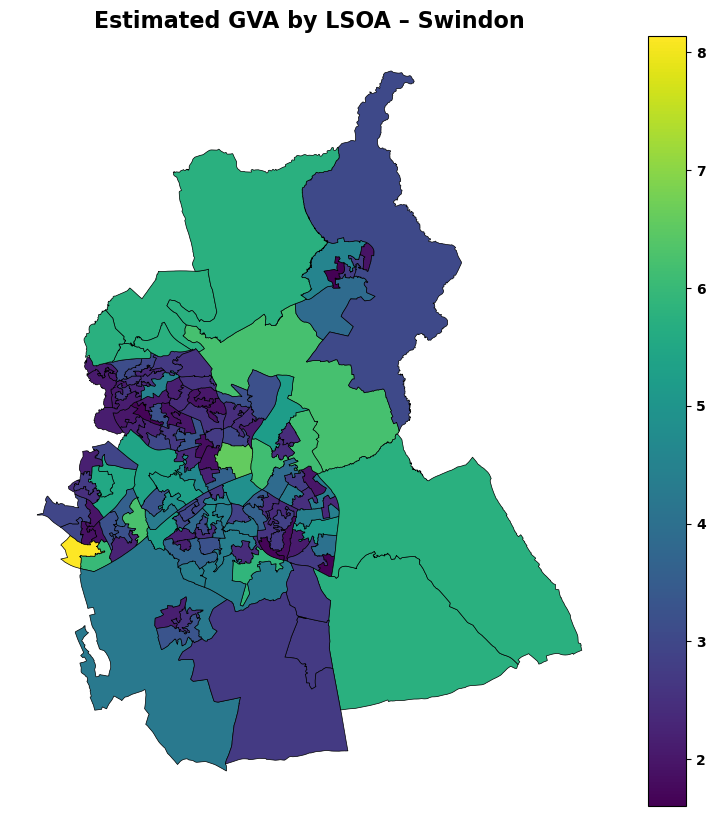

In [18]:

merged = swindon_lsoa.merge(df_swindon, on="LSOA21CD", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(
    column="log_gva",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Estimated GVA by LSOA – Swindon", fontsize=16)
ax.axis("off")
plt.show()

### 2. Employment Rate

In [19]:

print(df_swindon['employment_rate_per_pop'].describe())
print(f'\nValues > 2.0: {(df_swindon["employment_rate_per_pop"] > 2).sum()}')
print(f'Values > 1.0: {(df_swindon["employment_rate_per_pop"] > 1).sum()}')

count    140.000000
mean       0.443591
std        0.812756
min        0.000000
25%        0.059205
50%        0.137116
75%        0.381615
max        4.708314
Name: employment_rate_per_pop, dtype: float64

Values > 2.0: 6
Values > 1.0: 19


In [20]:
# Inspect the suspicious rows
df_swindon[df_swindon['employment_rate_per_pop'] > 2][['LSOA21NM', 'employment_rate_per_pop', 
                                        'total_employees', 'Mid-2024 population',
                                        'RUC21NM']].sort_values('employment_rate_per_pop', ascending=False)

,LSOA21NM,employment_rate_per_pop,total_employees,Mid-2024 population,RUC21NM
1,Swindon 008A,4.708314,10250,2177,Smaller rural: Nearer to a major town or city
87,Swindon 014B,4.438642,6800,1532,Urban: Nearer to a major town or city
70,Swindon 008C,3.994009,8000,2003,Smaller rural: Nearer to a major town or city
28,Swindon 022C,3.623747,4700,1297,Urban: Nearer to a major town or city
103,Swindon 012D,2.395965,3800,1586,Urban: Nearer to a major town or city
34,Swindon 010B,2.315789,4400,1900,Urban: Nearer to a major town or city


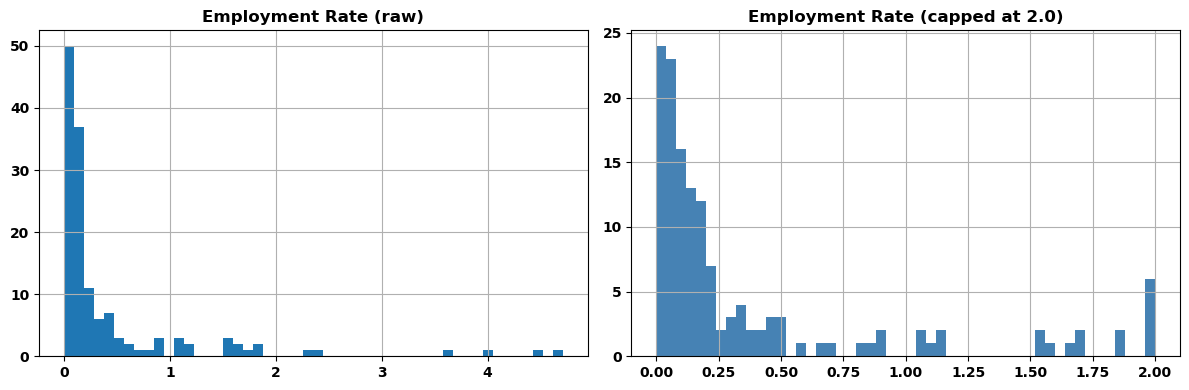

In [21]:
# Values >1 are real (more jobs than residents = commercial/commuter area)
# Values >2 need a decision — cap or investigate further
# For now: cap at 2.0, note this in your methods
df_swindon['emp_rate'] = df_swindon['employment_rate_per_pop'].clip(upper=2.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_swindon['employment_rate_per_pop'].hist(bins=50, ax=axes[0])
axes[0].set_title('Employment Rate (raw)')
df_swindon['emp_rate'].hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Employment Rate (capped at 2.0)')
plt.tight_layout()

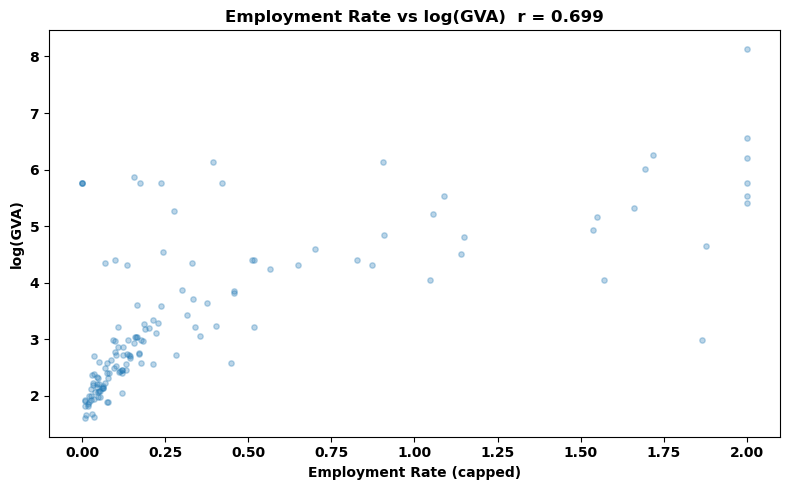

In [22]:
# Relationship with GVA
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_swindon['emp_rate'], df_swindon['log_gva'], alpha=0.3, s=15)
ax.set_xlabel('Employment Rate (capped)')
ax.set_ylabel('log(GVA)')
ax.set_title(f'Employment Rate vs log(GVA)  r = {df_swindon["emp_rate"].corr(df_swindon["log_gva"]):.3f}')
plt.tight_layout()

### 3. Economic Resilience

In [23]:
diversity_cols = ['turnover_diversity_1-HHI_2025_msoa', 'LU_diversity_1-HHI_2025']
print(df_swindon[diversity_cols].describe())

       turnover_diversity_1-HHI_2025_msoa  LU_diversity_1-HHI_2025
count                          140.000000               140.000000
mean                             0.786312                 0.895954
std                              0.038293                 0.021028
min                              0.730124                 0.849481
25%                              0.756198                 0.882223
50%                              0.771358                 0.904844
75%                              0.824332                 0.909617
max                              0.841564                 0.929012


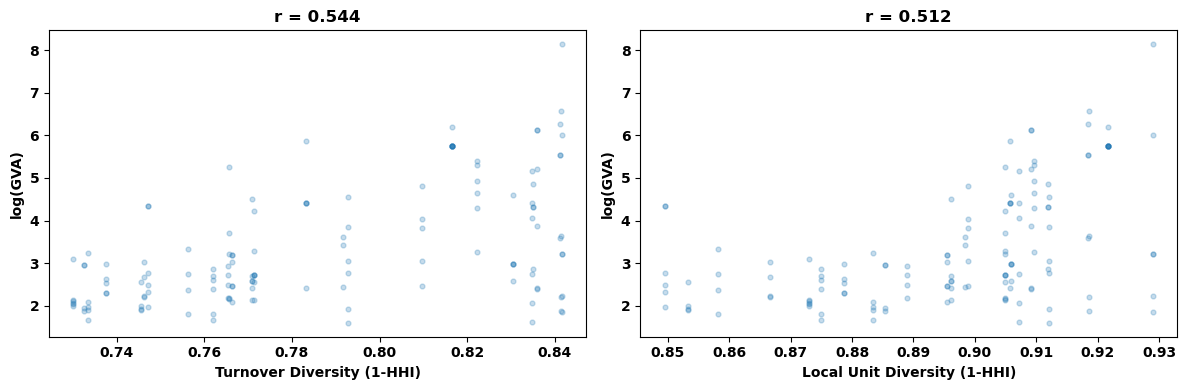

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Turnover Diversity (1-HHI)', 'Local Unit Diversity (1-HHI)']

for ax, col, label in zip(axes, diversity_cols, labels):
    r = df_swindon[col].corr(df_swindon['log_gva'])
    ax.scatter(df_swindon[col], df_swindon['log_gva'], alpha=0.25, s=12)
    ax.set_xlabel(label)
    ax.set_ylabel('log(GVA)')
    ax.set_title(f'r = {r:.3f}')

plt.tight_layout()

### 4. Business Size Structure

In [25]:
bss_cols = ['LU_pct_micro_2025_msoa', 'LU_pct_small_2025_msoa',
            'LU_pct_medium_2025_msoa', 'LU_pct_large_2025_msoa']

print('--- Mean business size distribution ---')
print(df_swindon[bss_cols].mean())
print()

# Do they sum to 1?
df_swindon['bss_sum'] = df_swindon[bss_cols].sum(axis=1)
print('--- Sum check (should be ~1.0) ---')
print(df_swindon['bss_sum'].describe())

--- Mean business size distribution ---
LU_pct_micro_2025_msoa     0.849698
LU_pct_small_2025_msoa     0.117869
LU_pct_medium_2025_msoa    0.027976
LU_pct_large_2025_msoa     0.004456
dtype: float64

--- Sum check (should be ~1.0) ---
count    1.400000e+02
mean     1.000000e+00
std      2.023668e-10
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: bss_sum, dtype: float64


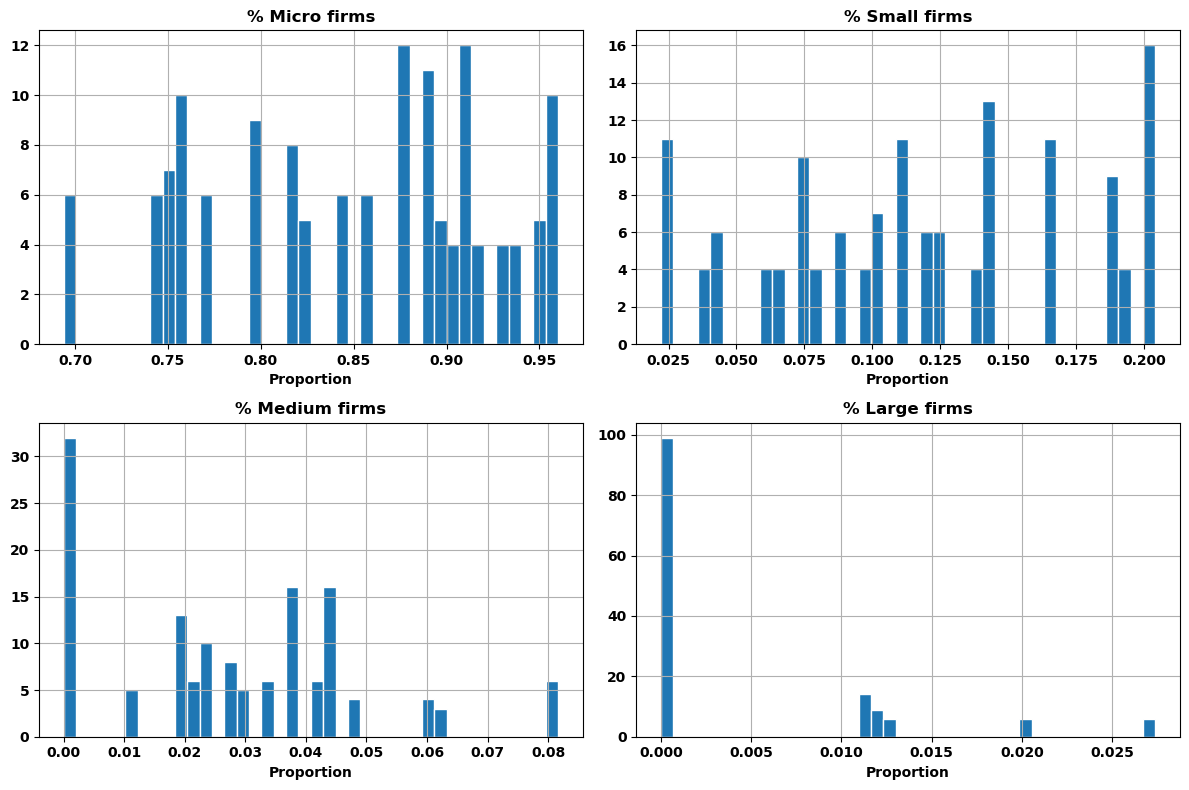

In [26]:
# Distribution of each size band
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels = ['Micro', 'Small', 'Medium', 'Large']

for ax, col, label in zip(axes.flatten(), bss_cols, labels):
    df_swindon[col].hist(bins=40, ax=ax, edgecolor='white')
    ax.set_title(f'% {label} firms')
    ax.set_xlabel('Proportion')

plt.tight_layout()

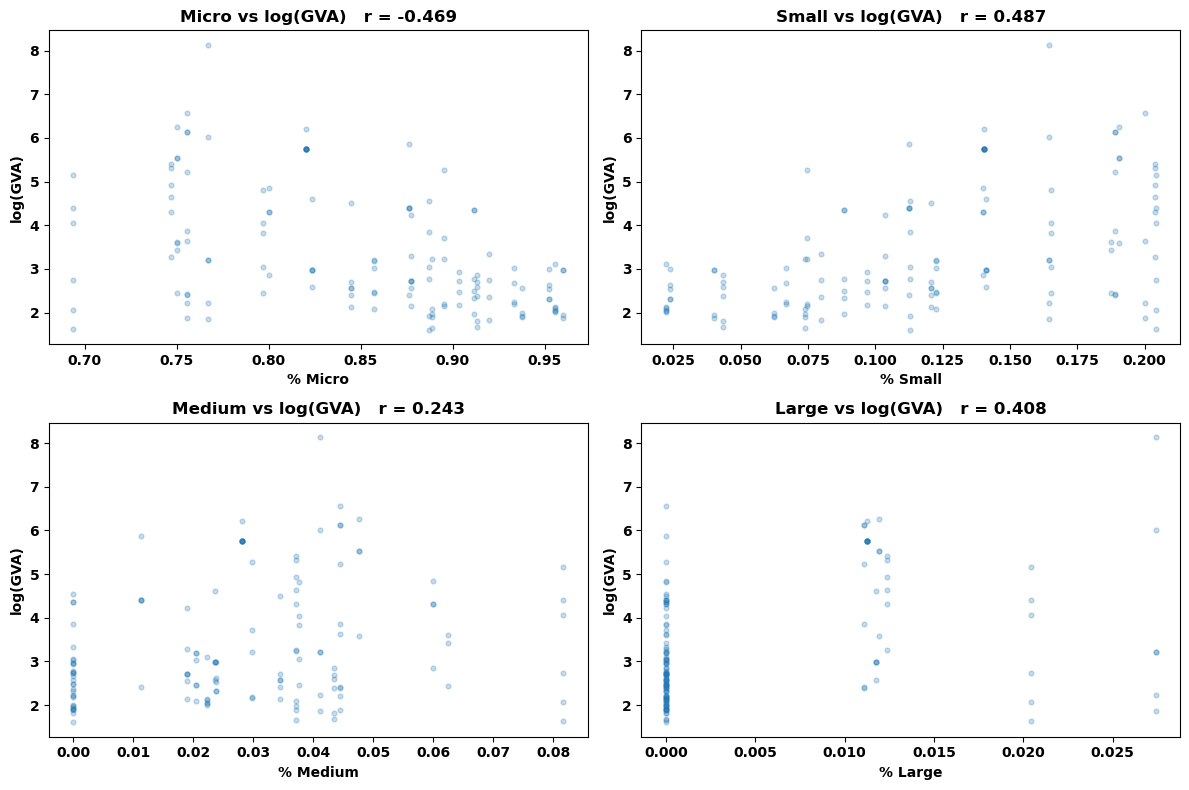

In [27]:
# Each vs log GVA
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, label in zip(axes.flatten(), bss_cols, labels):
    r = df_swindon[col].corr(df_swindon['log_gva'])
    ax.scatter(df_swindon[col], df_swindon['log_gva'], alpha=0.25, s=12)
    ax.set_xlabel(f'% {label}')
    ax.set_ylabel('log(GVA)')
    ax.set_title(f'{label} vs log(GVA)   r = {r:.3f}')

plt.tight_layout()

### 5. Sector Composition

In [28]:
sector_cols = [
    'share_enterprises_kibs_2025_msoa',
    'share_enterprises_foundational_2025_msoa',
    'share_enterprises_creative_2025_msoa',
    'share_enterprises_industrial_2025_msoa',
    'share_enterprises_green_aligned_2025_msoa',
    'share_enterprises_anchor_2025_msoa'
]

print('--- Sector share means ---')
print(df_swindon[sector_cols].mean().sort_values(ascending=False))
print()

print('--- Correlation with log(GVA) ---')
corrs = df_swindon[sector_cols + ['log_gva']].corr()['log_gva'].drop('log_gva').sort_values(ascending=False)
print(corrs)

--- Sector share means ---
share_enterprises_foundational_2025_msoa     0.494071
share_enterprises_kibs_2025_msoa             0.329746
share_enterprises_creative_2025_msoa         0.093603
share_enterprises_anchor_2025_msoa           0.061563
share_enterprises_green_aligned_2025_msoa    0.049534
share_enterprises_industrial_2025_msoa       0.042172
dtype: float64

--- Correlation with log(GVA) ---
share_enterprises_green_aligned_2025_msoa    0.247067
share_enterprises_industrial_2025_msoa       0.217536
share_enterprises_kibs_2025_msoa             0.148674
share_enterprises_anchor_2025_msoa           0.084870
share_enterprises_creative_2025_msoa         0.081684
share_enterprises_foundational_2025_msoa    -0.337886
Name: log_gva, dtype: float64


### 6. Deprivation - Policy Intervention

In [29]:
imd_cols = ['IMD_decile', 'Income_decile', 'Employment_decile', 
            'Education_decile', 'AdultSkills_decile']

print(df_swindon[imd_cols].describe())
print()
print('Correlation with log(GVA):')
print(df_swindon[imd_cols + ['log_gva']].corr()['log_gva'].drop('log_gva'))

       IMD_decile  Income_decile  Employment_decile  Education_decile  \
count  140.000000     140.000000         140.000000        140.000000   
mean     6.335714       5.957143           6.078571          4.900000   
std      2.715823       2.602908           2.693098          2.360649   
min      1.000000       1.000000           1.000000          1.000000   
25%      4.000000       4.000000           4.000000          3.000000   
50%      7.000000       6.000000           7.000000          5.000000   
75%      8.000000       8.000000           8.000000          6.250000   
max     10.000000      10.000000          10.000000         10.000000   

       AdultSkills_decile  
count          140.000000  
mean             4.678571  
std              2.516901  
min              1.000000  
25%              3.000000  
50%              4.500000  
75%              7.000000  
max             10.000000  

Correlation with log(GVA):
IMD_decile            0.115978
Income_decile         0.091778


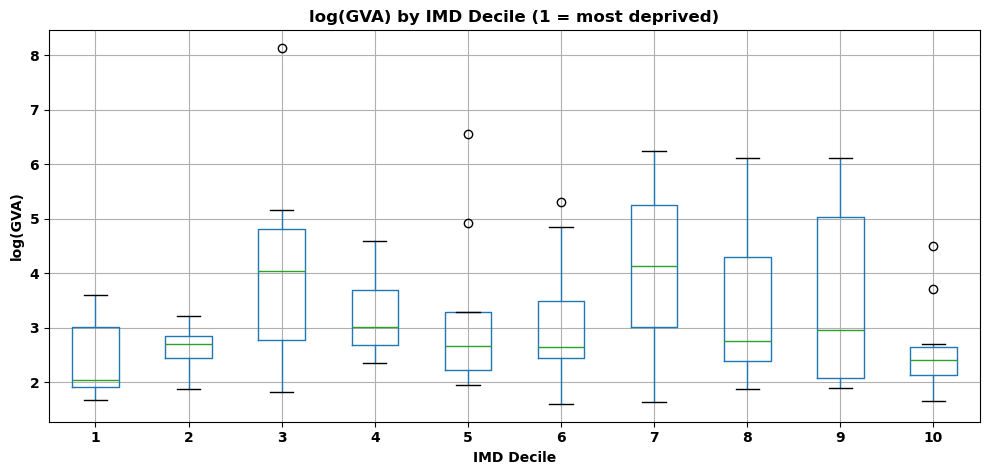

In [30]:
# GVA by IMD decile — does deprivation predict GVA?
fig, ax = plt.subplots(figsize=(10, 5))
df_swindon.boxplot(column='log_gva', by='IMD_decile', ax=ax)
ax.set_title('log(GVA) by IMD Decile (1 = most deprived)')
ax.set_xlabel('IMD Decile')
ax.set_ylabel('log(GVA)')
plt.suptitle('')
plt.tight_layout()

### 7. Correlation overview on DAG variables

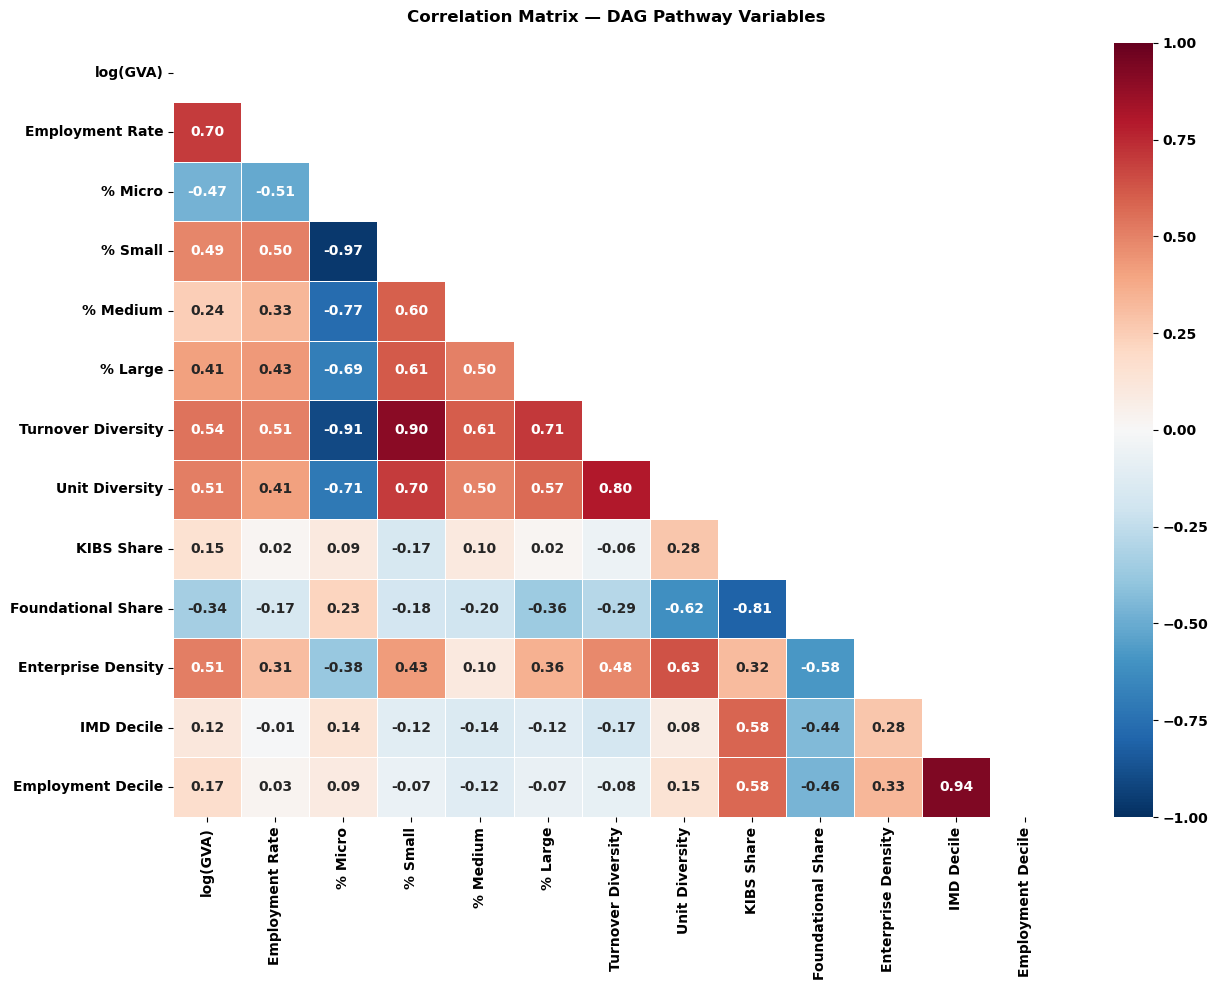

In [31]:
dag_vars = {
    'log_gva': 'log(GVA)',
    'emp_rate': 'Employment Rate',
    'LU_pct_micro_2025_msoa': '% Micro',
    'LU_pct_small_2025_msoa': '% Small',
    'LU_pct_medium_2025_msoa': '% Medium',
    'LU_pct_large_2025_msoa': '% Large',
    'turnover_diversity_1-HHI_2025_msoa': 'Turnover Diversity',
    'LU_diversity_1-HHI_2025': 'Unit Diversity',
    'share_enterprises_kibs_2025_msoa': 'KIBS Share',
    'share_enterprises_foundational_2025_msoa': 'Foundational Share',
    'enterprises_per_1k_residents_2025': 'Enterprise Density',
    'IMD_decile': 'IMD Decile',
    'Employment_decile': 'Employment Decile',
}

corr_df = df_swindon[list(dag_vars.keys())].rename(columns=dag_vars)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — DAG Pathway Variables', pad=15)
plt.tight_layout()